In [1]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")

In [2]:
NORMAL_FILES = [
    "data/cleaned_combined.csv",
]

CPU_COL  = "Processor_% Processor Time"
MEM_COL  = "Memory_Pages/sec"
IO_COL   = "Process_IO Data Bytes/sec"
IDLE_COL = "Processor_% Idle Time"

LABEL_COLS = {CPU_COL, MEM_COL, IO_COL, IDLE_COL}

LEAKY_COLS = {
    "Processor_% User Time",
    "Processor_% Privileged Time",
    "Processor_% DPC Time",
    "Processor_% Interrupt Time",
    "Processor_% C1 Time",
    "Processor_% C2 Time",
    "Processor_% C3 Time",
}

FEATURE_COLS = [
    "Processor_Interrupts/sec",
    "Processor_DPCs Queued/sec",
    "Processor_DPC Rate",
    "Process_IO Read Bytes/sec",
    "Process_IO Write Bytes/sec",
    "Process_IO Data Operations/sec",
    "Process_IO Read Operations/sec",
    "Process_Working Set",
    "Process_Working Set - Private",
    "Process_Page Faults/sec",
    "Process_Thread Count",
    "Process_Handle Count",
    "Memory_Page Faults/sec",
    "Memory_Demand Zero Faults/sec",
    "Memory_Available MBytes",
    "Memory_% Committed Bytes In Use",
    "Memory_Cache Faults/sec",
    "Memory_Transition Faults/sec",
    "Memory_Pages Input/sec",
    "Memory_Pages Output/sec",
    "Memory_Pages/sec",
]

In [3]:
TEST_SIZE      = 0.25
RANDOM_SEED    = 42
MAX_ITER       = 1000
CV_FOLDS       = 5
SOLVER         = "lbfgs"
TOP_N_FEATURES = 10

In [4]:
def strip_host(col: str) -> str:
    return re.sub(r"^\\\\[^\\]+\\", "", col).strip()


def load_pdh_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, low_memory=False)
    df.columns = [strip_host(c) if i > 0 else "ts" for i, c in enumerate(df.columns)]
    df = df.drop(columns=["ts"], errors="ignore")
    df = df.replace(" ", np.nan)
    return pd.to_numeric(df.stack(), errors="coerce").unstack()


def load_data() -> tuple:
    data = pd.read_csv("data/cleaned_combined.csv", low_memory=False)
    common = [
        c for c in data.columns
        if c not in ["timestamp", "os", "label", "source_file"]
]
    data = data.dropna(thresh=int(0.2 * len(common)))
    return data, common


def assign_load_state(df: pd.DataFrame) -> pd.Series:
    cpu = df[CPU_COL].fillna(0)
    mem = df[MEM_COL].fillna(0)
    io  = df[IO_COL].fillna(0)

    state = pd.Series("Active", index=df.index)
    state[cpu >= 30] = "Stressed"
    state[(mem > 200) & (io > 1e6)] = "Stressed"
    state[(cpu < 5) & (io < 5e4)] = "Idle"
    return state

In [5]:
def plot_confusion_matrix(y_test: np.ndarray, y_pred: np.ndarray, classes: list):
    cm = confusion_matrix(y_test, y_pred, labels=classes)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title("Confusion Matrix — Load State Classifier")
    plt.tight_layout()
    plt.show()

In [6]:
def plot_roc_curves(y_test: np.ndarray, y_prob: np.ndarray, classes: list):
    y_bin = label_binarize(y_test, classes=classes)
    fig, ax = plt.subplots(figsize=(7, 6))
    colors = ["#378ADD", "#1D9E75", "#E24B4A"]

    for i, (cls, color) in enumerate(zip(classes, colors)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{cls} (AUC = {roc_auc:.3f})")

    ax.plot([0, 1], [0, 1], "k--", linewidth=1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("One-vs-Rest ROC Curves — Load State")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

In [7]:
def plot_top_coefficients(model: LogisticRegression, feat_cols: list, classes: list):
    fig, axes = plt.subplots(1, len(classes), figsize=(6 * len(classes), 5), sharey=False)

    for ax, cls, coef in zip(axes, classes, model.coef_):
        coef_s = pd.Series(coef, index=[c.split("\\")[-1] for c in feat_cols])
        top = coef_s.abs().nlargest(TOP_N_FEATURES).index
        coef_top = coef_s[top].sort_values()
        colors = ["#E24B4A" if v > 0 else "#378ADD" for v in coef_top]
        coef_top.plot(kind="barh", ax=ax, color=colors)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_title(f"Top Coefficients — {cls}")
        ax.set_xlabel("Coefficient value")

    plt.tight_layout()
    plt.show()

Loading cleaned dataset ...
Load state distribution:
load_state
Active      16564
Stressed     8438
Idle         4144

Samples: 29146   Features: 21

Cross-validation accuracy (5-fold): 0.8846 +/- 0.0048

LOGISTIC REGRESSION — EVALUATION
              precision    recall  f1-score   support

      Active       0.86      0.95      0.90      4141
        Idle       0.97      0.98      0.97      1036
    Stressed       0.90      0.70      0.79      2110

    accuracy                           0.88      7287
   macro avg       0.91      0.88      0.89      7287
weighted avg       0.89      0.88      0.88      7287

Accuracy : 0.8839


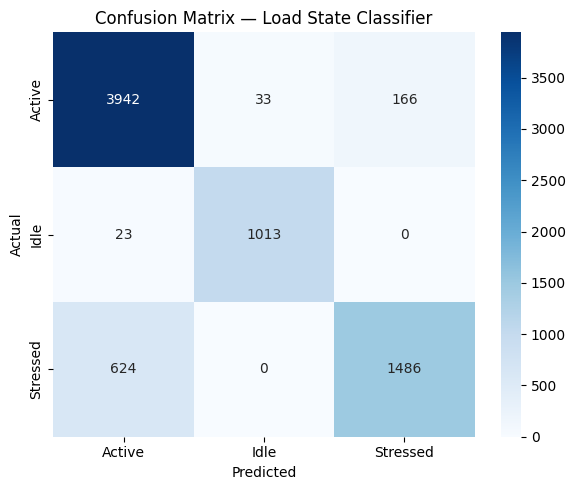

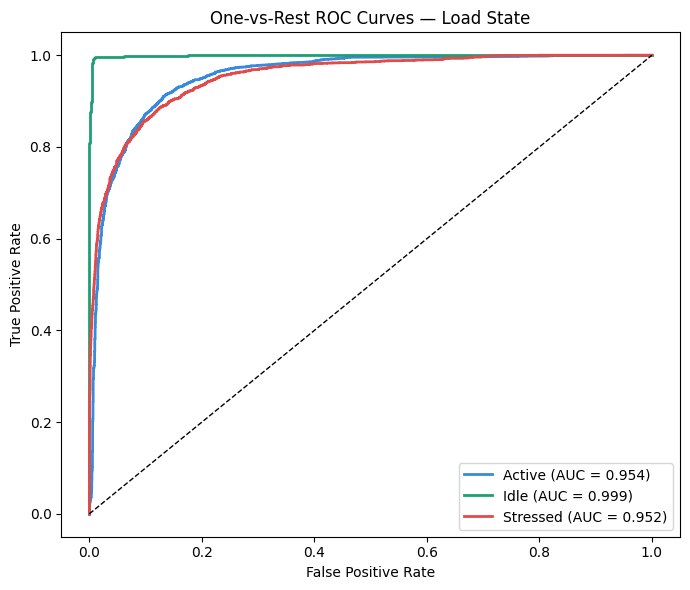

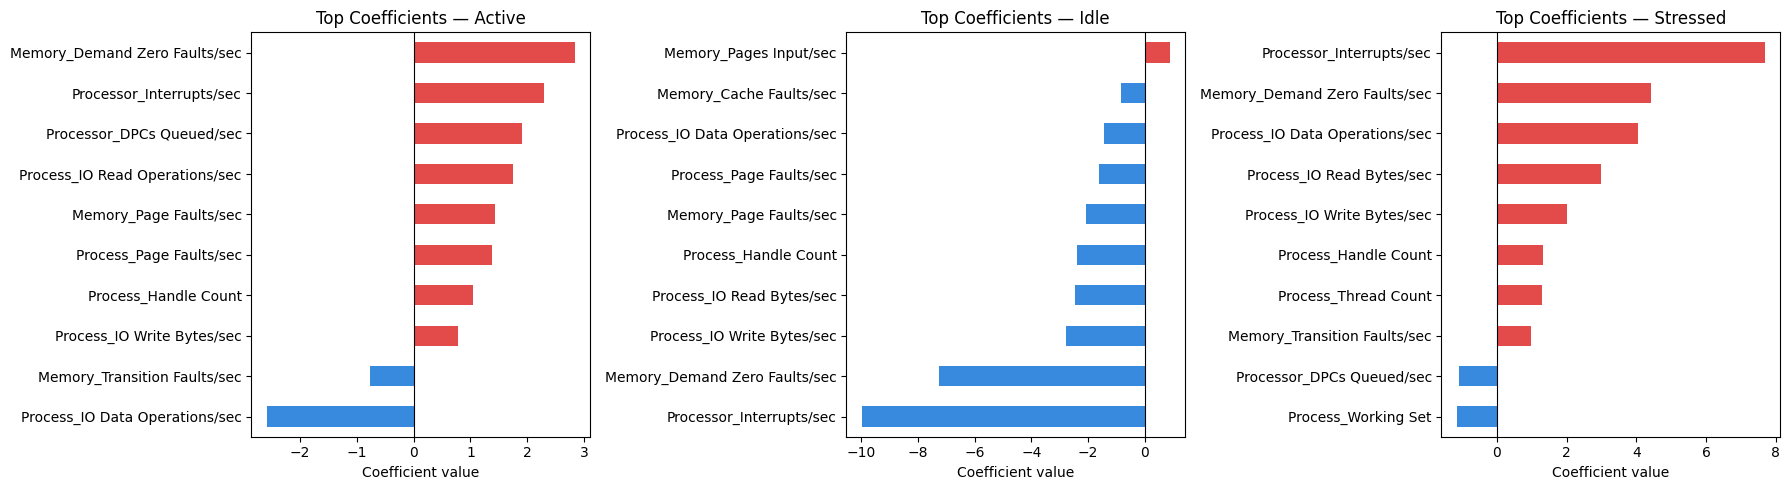

In [8]:
print("Loading cleaned dataset ...")
data, common = load_data()

data["load_state"] = assign_load_state(data)
print("Load state distribution:")
print(data["load_state"].value_counts().to_string())

feat_cols = [c for c in FEATURE_COLS if c in common]
if not feat_cols:
    feat_cols = [c for c in common if c not in LABEL_COLS]
print(f"\nSamples: {len(data)}   Features: {len(feat_cols)}")

X = data[feat_cols].fillna(0)
y = data["load_state"]

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

model = LogisticRegression(
    multi_class="multinomial",
    solver=SOLVER,
    max_iter=MAX_ITER,
    random_state=RANDOM_SEED,
)
model.fit(X_tr_s, y_tr)

cv_scores = cross_val_score(model, X_tr_s, y_tr, cv=CV_FOLDS, scoring="accuracy")
print(f"\nCross-validation accuracy ({CV_FOLDS}-fold): "
        f"{cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

y_pred = model.predict(X_te_s)
y_prob = model.predict_proba(X_te_s)

print("\n" + "=" * 50)
print("LOGISTIC REGRESSION — EVALUATION")
print("=" * 50)
print(classification_report(y_te, y_pred, target_names=model.classes_))
print(f"Accuracy : {accuracy_score(y_te, y_pred):.4f}")
print("=" * 50)

classes_ordered = list(model.classes_)

plot_confusion_matrix(y_te.to_numpy(), y_pred, classes_ordered)
plot_roc_curves(y_te.to_numpy(), y_prob, classes_ordered)
plot_top_coefficients(model, feat_cols, classes_ordered)